# 06_baseline_modeling.ipynb

## Ρόλος του notebook

Το `NB06` αποτελεί το **canonical baseline modeling stage** του forecasting pipeline και περιορίζεται αυστηρά στα εξής:

- **Persistence baseline**
- **Linear Regression baseline**
- **baseline comparison**
- **residual diagnostics**
- **actual-vs-predicted analysis**

Το notebook **δεν** κάνει:

- νέο feature engineering
- νέο temporal split
- νέο outlier handling
- benchmark consolidation πέρα από τα δικά του models
- scope expansion προς advanced models

---

## Upstream contract

Το notebook διαβάζει **μόνο** τα canonical split artifacts του `NB05`:

- `data/processed/train_final.csv`
- `data/processed/val_final.csv`
- `data/processed/test_final.csv`

Άρα το `NB06` λειτουργεί ως **consume-only downstream stage** πάνω στο ήδη σταθεροποιημένο feature / split contract.

---

## Methodological principles

Το notebook επιβάλλει ρητά ότι:

- target είναι μόνο το `Power_Output_Normalized`
- οι learned-model inputs **δεν** περιλαμβάνουν:
  - `timestamp`
  - `park_id`
  - `test_flag`
  - `Baseline_Prediction`
- το learned feature space είναι identical across `train / val / test`
- τα validation metrics χρησιμοποιούνται **μόνο για interpretation**
- το `data/processed/baseline_metrics.csv` παραμένει **canonical final test-set benchmark artifact**
- τα diagnostics παραμένουν **forecasting-oriented** και όχι PHM claims

---

## Downstream handoff

Το notebook εξάγει:

- `data/processed/baseline_metrics.csv`
  - μόνο με **test rows**
  - μόνο με canonical benchmark schema

- `data/processed/nb06_test_predictions.csv`
  - tidy row-level test predictions
  - για downstream diagnostics notebooks

Το notebook δεν προδικάζει ότι κάποιο baseline είναι “γενικά καλύτερο” χωρίς metric-qualified έλεγχο.
Η τελική ερμηνεία πρέπει να βασίζεται στα πραγματικά outputs του τρέχοντος rerun.

In [1]:
# ============================================================
# NB06 | Imports
# ============================================================

from __future__ import annotations

from pathlib import Path
import sys
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------------------
# Display / plotting defaults
# ------------------------------------------------------------

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid")

In [2]:
# ============================================================
# NB06 | Path helpers και core utilities
# ============================================================

def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το project root ανεβαίνοντας από το current working directory.

    Απαιτούμε να υπάρχουν τουλάχιστον οι φάκελοι:
    - data/
    - notebooks/
    """
    current = start_path.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Δεν βρέθηκε project root με φακέλους 'data/' και 'notebooks/'."
    )


def load_split(csv_path: Path, park_id_col: str, timestamp_col: str) -> pd.DataFrame:
    """
    Φορτώνει canonical split artifact με strict parsing.

    Κρατάμε:
    - park_id ως string
    - timestamp με strict downstream format
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"Λείπει required split artifact: {csv_path}")

    df = pd.read_csv(csv_path, dtype={park_id_col: "string"})

    if timestamp_col not in df.columns:
        raise KeyError(
            f"Λείπει η timestamp στήλη `{timestamp_col}` από το {csv_path.name}"
        )

    df[park_id_col] = df[park_id_col].astype("string")
    df[timestamp_col] = pd.to_datetime(
        df[timestamp_col],
        format="%Y-%m-%d %H:%M:%S",
        errors="raise",
    )

    return df


def assert_required_columns(
    df: pd.DataFrame,
    required_columns: set[str],
    split_name: str,
) -> None:
    """
    Ελέγχει ότι υπάρχουν όλα τα required backbone columns.
    """
    missing = sorted(required_columns - set(df.columns))
    if missing:
        raise KeyError(
            f"Λείπουν required columns από το split `{split_name}`: {missing}"
        )


def assert_no_duplicate_backbone(
    df: pd.DataFrame,
    split_name: str,
    park_id_col: str,
    timestamp_col: str,
) -> None:
    """
    Δεν επιτρέπουμε duplicate rows ως προς:
    (park_id, timestamp)
    """
    dup_mask = df.duplicated(subset=[park_id_col, timestamp_col], keep=False)

    if dup_mask.any():
        dup_preview = df.loc[dup_mask, [park_id_col, timestamp_col]].head(10)
        raise ValueError(
            f"Βρέθηκαν duplicate backbone rows στο split `{split_name}`.\n"
            f"{dup_preview.to_string(index=False)}"
        )


def assert_flag_contract(
    df: pd.DataFrame,
    split_name: str,
    flag_col: str,
    allowed_values: set[int],
) -> None:
    """
    Ελέγχει το expected contract του test_flag ανά split.
    """
    observed = set(pd.Series(df[flag_col]).dropna().astype(int).unique().tolist())

    if observed != allowed_values:
        raise ValueError(
            f"Παραβίαση test_flag contract στο split `{split_name}`. "
            f"Observed={observed}, Expected={allowed_values}"
        )


def assert_no_key_overlap(
    left_df: pd.DataFrame,
    right_df: pd.DataFrame,
    left_name: str,
    right_name: str,
    park_id_col: str,
    timestamp_col: str,
) -> None:
    """
    Ελέγχει ότι δεν υπάρχει overlap σε canonical keys
    μεταξύ δύο splits.
    """
    overlap = left_df[[park_id_col, timestamp_col]].merge(
        right_df[[park_id_col, timestamp_col]],
        on=[park_id_col, timestamp_col],
        how="inner",
    )

    if not overlap.empty:
        raise ValueError(
            f"Βρέθηκε overlap μεταξύ `{left_name}` και `{right_name}`: "
            f"{len(overlap):,} rows"
        )


def assert_all_finite_array(values, name: str) -> None:
    """
    Ελέγχει ότι ένα array-like περιέχει μόνο finite τιμές.
    """
    arr = np.asarray(values, dtype=float)

    if not np.isfinite(arr).all():
        raise ValueError(f"Βρέθηκαν non-finite τιμές στο `{name}`.")


def assert_all_finite_frame(df: pd.DataFrame, name: str) -> None:
    """
    Ελέγχει ότι ένα numeric dataframe περιέχει μόνο finite τιμές.
    """
    arr = df.to_numpy(dtype=float)

    if not np.isfinite(arr).all():
        raise ValueError(f"Βρέθηκαν non-finite τιμές στο dataframe `{name}`.")


def compute_metrics(y_true, y_pred, model_name: str) -> dict[str, float | str]:
    """
    Υπολογίζει τα canonical benchmark metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
    }


def atomic_to_csv(df: pd.DataFrame, path: Path, index: bool = False) -> None:
    """
    Safe overwrite / atomic replace για CSV export.
    """
    path.parent.mkdir(parents=True, exist_ok=True)

    with tempfile.NamedTemporaryFile(
        mode="w",
        suffix=".csv",
        prefix=f"{path.stem}_tmp_",
        dir=str(path.parent),
        delete=False,
        encoding="utf-8",
        newline=""
    ) as tmp_file:
        tmp_path = Path(tmp_file.name)

    try:
        df.to_csv(tmp_path, index=index)
        os.replace(tmp_path, path)
    finally:
        if tmp_path.exists():
            tmp_path.unlink(missing_ok=True)


def build_seeded_persistence(
    previous_split_df: pd.DataFrame,
    current_split_df: pd.DataFrame,
    park_id_col: str,
    timestamp_col: str,
    target_col: str,
    pred_col: str = "Persistence_Pred",
) -> pd.DataFrame:
    """
    Κατασκευάζει full-support persistence baseline.

    Λογική:
    - μέσα στο current split: prediction = προηγούμενο actual του ίδιου park
    - για την πρώτη γραμμή κάθε park: seeding από το τελευταίο actual
      του previous split

    Έτσι αποφεύγουμε trimming της πρώτης γραμμής κάθε park
    και διατηρούμε πλήρες benchmark support.
    """
    prev_sorted = (
        previous_split_df
        .sort_values([park_id_col, timestamp_col], kind="mergesort")
        .reset_index(drop=True)
        .copy()
    )

    curr_sorted = (
        current_split_df
        .sort_values([park_id_col, timestamp_col], kind="mergesort")
        .reset_index(drop=True)
        .copy()
    )

    # Τελευταίο actual target από το previous split ανά park
    prev_last_actual = prev_sorted.groupby(park_id_col, sort=False)[target_col].last()

    # Persistence μέσα στο current split
    curr_sorted[pred_col] = (
        curr_sorted
        .groupby(park_id_col, sort=False)[target_col]
        .shift(1)
    )

    # Seed για την πρώτη γραμμή κάθε park
    first_row_mask = (
        curr_sorted
        .groupby(park_id_col, sort=False)
        .cumcount()
        .eq(0)
    )

    curr_sorted.loc[first_row_mask, pred_col] = (
        curr_sorted.loc[first_row_mask, park_id_col]
        .map(prev_last_actual)
    )

    missing_seed = (
        curr_sorted.loc[first_row_mask & curr_sorted[pred_col].isna(), park_id_col]
        .drop_duplicates()
        .tolist()
    )

    if missing_seed:
        raise ValueError(
            "Αποτυχία persistence seeding για parks χωρίς previous history: "
            f"{missing_seed[:10]}"
        )

    if curr_sorted[pred_col].isna().any():
        raise ValueError(
            f"Παρέμειναν NaN persistence predictions "
            f"({int(curr_sorted[pred_col].isna().sum())} rows)."
        )

    return curr_sorted

In [3]:
# ============================================================
# NB06 | Constants και canonical paths
# ============================================================

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

TRAIN_PATH = DATA_PROCESSED / "train_final.csv"
VAL_PATH = DATA_PROCESSED / "val_final.csv"
TEST_PATH = DATA_PROCESSED / "test_final.csv"

BENCHMARK_PATH = DATA_PROCESSED / "baseline_metrics.csv"
NB06_TEST_PREDICTIONS_PATH = DATA_PROCESSED / "nb06_test_predictions.csv"

PARK_ID_COLUMN = "park_id"
TIMESTAMP_COLUMN = "timestamp"
FLAG_COLUMN = "test_flag"
TARGET_COLUMN = "Power_Output_Normalized"
BASELINE_COLUMN = "Baseline_Prediction"

REQUIRED_COLUMNS = {
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    FLAG_COLUMN,
    TARGET_COLUMN,
    BASELINE_COLUMN,
}

# Στήλες που δεν επιτρέπεται να μπουν στο learned feature space
BLOCKED_COLUMNS = {
    TARGET_COLUMN,
    TIMESTAMP_COLUMN,
    PARK_ID_COLUMN,
    FLAG_COLUMN,
    BASELINE_COLUMN,
    "Persistence_Pred",
    "y_true",
    "y_pred",
    "model",
}

# Μόνο τα NB06 models
NB06_MODELS = {"Persistence", "Linear Regression"}

# Canonical benchmark allowlist του current repo
CANONICAL_BENCHMARK_MODELS = {
    "Persistence",
    "Linear Regression",
    "Random Forest",
    "XGBoost",
    "MLP",
}

BENCHMARK_COLUMNS = ["Model", "MAE", "RMSE", "R2"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)
print("TRAIN_PATH:", TRAIN_PATH)
print("VAL_PATH:", VAL_PATH)
print("TEST_PATH:", TEST_PATH)
print("BENCHMARK_PATH:", BENCHMARK_PATH)
print("NB06_TEST_PREDICTIONS_PATH:", NB06_TEST_PREDICTIONS_PATH)

PROJECT_ROOT: C:\Users\diony\Desktop\WindPower_DigitalTwin
DATA_PROCESSED: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed
TRAIN_PATH: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\train_final.csv
VAL_PATH: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\val_final.csv
TEST_PATH: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\test_final.csv
BENCHMARK_PATH: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\baseline_metrics.csv
NB06_TEST_PREDICTIONS_PATH: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\nb06_test_predictions.csv


## Φόρτωση canonical split artifacts

Το `NB06` διαβάζει μόνο τα outputs του `NB05`.

Σε αυτό το στάδιο:

- δεν ξαναγίνεται split
- δεν ξαναγίνεται outlier handling
- δεν ξαναγίνεται feature engineering

Ο ρόλος του notebook είναι αυστηρά να καταναλώσει τα upstream canonical artifacts
και να εκτελέσει μόνο baseline modeling και diagnostics.

In [4]:
# ============================================================
# NB06 | Φόρττωση canonical split artifacts
# ============================================================

train_raw = load_split(TRAIN_PATH, PARK_ID_COLUMN, TIMESTAMP_COLUMN)
val_raw = load_split(VAL_PATH, PARK_ID_COLUMN, TIMESTAMP_COLUMN)
test_raw = load_split(TEST_PATH, PARK_ID_COLUMN, TIMESTAMP_COLUMN)

print("Η φόρτωση των canonical split artifacts ολοκληρώθηκε επιτυχώς.")
print(f"train_raw shape: {train_raw.shape}")
print(f"val_raw shape:   {val_raw.shape}")
print(f"test_raw shape:  {test_raw.shape}")

Η φόρτωση των canonical split artifacts ολοκληρώθηκε επιτυχώς.
train_raw shape: (1982736, 47)
val_raw shape:   (182998, 47)
test_raw shape:  (1086336, 47)


## Split integrity audit

Πριν εκπαιδευτεί οποιοδήποτε baseline, το notebook ελέγχει αυστηρά ότι:

- υπάρχουν όλα τα required backbone columns
- δεν υπάρχουν duplicate `(park_id, timestamp)` rows
- το raw schema είναι identical across `train / val / test`
- το `test_flag` contract τηρείται σωστά
- δεν υπάρχουν nulls ή non-finite τιμές στα core fields
- δεν υπάρχει overlap σε `(park_id, timestamp)` μεταξύ splits

Αυτό είναι σκόπιμα fail-fast, ώστε το `NB06` να μην προχωρά ποτέ πάνω σε corrupted ή ambiguous input state.

In [5]:
# ============================================================
# NB06 | Integrity audit των splits
# ============================================================

for split_name, df in [
    ("train", train_raw),
    ("val", val_raw),
    ("test", test_raw),
]:
    # Required columns
    assert_required_columns(df, REQUIRED_COLUMNS, split_name)

    # Duplicate backbone rows
    assert_no_duplicate_backbone(
        df,
        split_name,
        PARK_ID_COLUMN,
        TIMESTAMP_COLUMN,
    )

    # Core null checks
    core_nulls = df[[PARK_ID_COLUMN, TIMESTAMP_COLUMN, FLAG_COLUMN, TARGET_COLUMN]].isnull().sum()
    if int(core_nulls.sum()) > 0:
        raise ValueError(
            f"Βρέθηκαν nulls στα core columns του split `{split_name}`:\n"
            f"{core_nulls.to_string()}"
        )

# Raw schema must be identical across splits
train_columns = list(train_raw.columns)
val_columns = list(val_raw.columns)
test_columns = list(test_raw.columns)

if train_columns != val_columns or train_columns != test_columns:
    raise ValueError(
        "Το raw schema δεν είναι identical across train / val / test."
    )

# test_flag contract
assert_flag_contract(train_raw, "train", FLAG_COLUMN, {0})
assert_flag_contract(val_raw, "val", FLAG_COLUMN, {0})
assert_flag_contract(test_raw, "test", FLAG_COLUMN, {1})

# Non-empty splits
if len(train_raw) == 0 or len(val_raw) == 0 or len(test_raw) == 0:
    raise ValueError("Ένα ή περισσότερα splits είναι κενά.")

# Deterministic ordering
train_df = (
    train_raw
    .sort_values([PARK_ID_COLUMN, TIMESTAMP_COLUMN], kind="mergesort")
    .reset_index(drop=True)
    .copy()
)

val_df = (
    val_raw
    .sort_values([PARK_ID_COLUMN, TIMESTAMP_COLUMN], kind="mergesort")
    .reset_index(drop=True)
    .copy()
)

test_df = (
    test_raw
    .sort_values([PARK_ID_COLUMN, TIMESTAMP_COLUMN], kind="mergesort")
    .reset_index(drop=True)
    .copy()
)

# Cross-split overlap checks
assert_no_key_overlap(train_df, val_df, "train", "val", PARK_ID_COLUMN, TIMESTAMP_COLUMN)
assert_no_key_overlap(train_df, test_df, "train", "test", PARK_ID_COLUMN, TIMESTAMP_COLUMN)
assert_no_key_overlap(val_df, test_df, "val", "test", PARK_ID_COLUMN, TIMESTAMP_COLUMN)

# Target finite checks
assert_all_finite_array(train_df[TARGET_COLUMN], "train target")
assert_all_finite_array(val_df[TARGET_COLUMN], "val target")
assert_all_finite_array(test_df[TARGET_COLUMN], "test target")

print("Το split integrity audit ολοκληρώθηκε επιτυχώς.")
print(f"train_df shape: {train_df.shape}")
print(f"val_df shape:   {val_df.shape}")
print(f"test_df shape:  {test_df.shape}")

Το split integrity audit ολοκληρώθηκε επιτυχώς.
train_df shape: (1982736, 47)
val_df shape:   (182998, 47)
test_df shape:  (1086336, 47)


## Feature / target contract audit

Το `NB06` επιβάλλει ρητά ότι:

- target είναι μόνο το `Power_Output_Normalized`
- το learned feature space αποκλείει:
  - `timestamp`
  - `park_id`
  - `test_flag`
  - `Baseline_Prediction`
- χρησιμοποιούνται μόνο **numeric learned features**
- το feature order παραμένει identical across `train / val / test`
- δεν υπάρχουν null ή non-finite τιμές στο τελικό modeling matrix

Το notebook δεν υποθέτει ότι κάθε numeric στήλη είναι αυτομάτως αποδεκτή ως modeling input.
Πρώτα αφαιρούνται όλες οι blocked columns και μετά γίνεται αυστηρός numeric audit.

In [6]:
# ============================================================
# NB06 | Αυστηρός έλεγχος feature / target contract
# ============================================================

# Ρητή επιβεβαίωση target contract
assert TARGET_COLUMN == "Power_Output_Normalized", (
    f"Unexpected target column: {TARGET_COLUMN}"
)

# Candidate features = όλα τα columns εκτός από blocked
candidate_feature_cols = [
    col for col in train_df.columns
    if col not in BLOCKED_COLUMNS
]

if not candidate_feature_cols:
    raise ValueError("Δεν βρέθηκαν candidate features μετά το initial feature audit.")

# Learned features = μόνο numeric candidate features
feature_cols = [
    col for col in candidate_feature_cols
    if pd.api.types.is_numeric_dtype(train_df[col])
]

dropped_non_numeric_features = [
    col for col in candidate_feature_cols
    if col not in feature_cols
]

print("Μη numeric candidate features που αποκλείστηκαν από το NB06:")
print(dropped_non_numeric_features)

if not feature_cols:
    raise ValueError("Δεν βρέθηκαν numeric learned features μετά το feature audit.")

# Καμία blocked στήλη δεν επιτρέπεται στο feature space
illegal_features = sorted(set(feature_cols) & BLOCKED_COLUMNS)
if illegal_features:
    raise ValueError(
        f"Blocked columns βρέθηκαν κατά λάθος στο feature space: {illegal_features}"
    )

# Όλες οι learned features πρέπει να υπάρχουν και στα 3 splits
for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df),
]:
    missing_features = [col for col in feature_cols if col not in df.columns]
    if missing_features:
        raise KeyError(
            f"Λείπουν learned features από το split `{split_name}`: {missing_features}"
        )

# Όλες οι learned features πρέπει να είναι numeric και στα 3 splits
for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df),
]:
    non_numeric = [
        col for col in feature_cols
        if not pd.api.types.is_numeric_dtype(df[col])
    ]
    if non_numeric:
        raise TypeError(
            f"Μη numeric learned features στο split `{split_name}`: {non_numeric}"
        )

# Null checks στο learned feature space
for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df),
]:
    null_counts = df[feature_cols].isnull().sum()
    null_counts = null_counts[null_counts > 0]

    if not null_counts.empty:
        raise ValueError(
            f"Βρέθηκαν nulls στο learned feature space του split `{split_name}`:\n"
            f"{null_counts.to_string()}"
        )

# Τελικές matrices
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_COLUMN].copy()

X_val_full = val_df[feature_cols].copy()
y_val_full = val_df[TARGET_COLUMN].copy()

X_test_full = test_df[feature_cols].copy()
y_test_full = test_df[TARGET_COLUMN].copy()

# Finite checks
assert_all_finite_frame(X_train, "X_train")
assert_all_finite_frame(X_val_full, "X_val_full")
assert_all_finite_frame(X_test_full, "X_test_full")

assert_all_finite_array(y_train, "y_train")
assert_all_finite_array(y_val_full, "y_val_full")
assert_all_finite_array(y_test_full, "y_test_full")

print(f"Συνολικός αριθμός numeric learned features: {len(feature_cols)}")
print("Πρώτες 20 learned features:")
print(feature_cols[:20])

print("\nΣχήματα matrices:")
print(f"X_train:     {X_train.shape}")
print(f"X_val_full:  {X_val_full.shape}")
print(f"X_test_full: {X_test_full.shape}")

Μη numeric candidate features που αποκλείστηκαν από το NB06:
['turbine']
Συνολικός αριθμός numeric learned features: 41
Πρώτες 20 learned features:
['hub_height_m', 'rotor_diameter_m', 'nominal_power_kW', 'lat', 'long', 'nwp_fcst_horiz_hours', 'T_HAG_2_M', 'RELHUM_HAG_2_M', 'PS_SFC_0_M', 'U_GVL_58_HL', 'V_GVL_58_HL', 'U_GVL_60_HL', 'V_GVL_60_HL', 'ASWDIFDS_SFC_0_M', 'ASWDIRS_SFC_0_M', 'U_GVL_58_HL_m1', 'V_GVL_58_HL_m1', 'U_GVL_60_HL_m1', 'V_GVL_60_HL_m1', 'U_GVL_58_HL_p1']

Σχήματα matrices:
X_train:     (1982736, 41)
X_val_full:  (182998, 41)
X_test_full: (1086336, 41)


## Persistence baseline με full split support

Το persistence baseline πρέπει να είναι **δίκαιο baseline** και όχι trimmed artifact.

Για αυτό:

- στο validation split, η πρώτη γραμμή κάθε park seeded-άρεται από το τελευταίο actual του train
- στο test split, η πρώτη γραμμή κάθε park seeded-άρεται από το τελευταίο actual του validation

Έτσι αποφεύγουμε να χάνουμε rows στην αρχή κάθε split και διατηρούμε **full evaluation support**.

In [7]:
# ============================================================
# NB06 | Full-support Persistence baseline
# ============================================================

# Validation persistence
val_eval = build_seeded_persistence(
    previous_split_df=train_df,
    current_split_df=val_df,
    park_id_col=PARK_ID_COLUMN,
    timestamp_col=TIMESTAMP_COLUMN,
    target_col=TARGET_COLUMN,
    pred_col="Persistence_Pred",
)

# Test persistence
test_eval = build_seeded_persistence(
    previous_split_df=val_df,
    current_split_df=test_df,
    park_id_col=PARK_ID_COLUMN,
    timestamp_col=TIMESTAMP_COLUMN,
    target_col=TARGET_COLUMN,
    pred_col="Persistence_Pred",
)

# Aligned matrices με το evaluation order
X_val = val_eval[feature_cols].copy()
y_val = val_eval[TARGET_COLUMN].copy()

X_test = test_eval[feature_cols].copy()
y_test = test_eval[TARGET_COLUMN].copy()

# Full-support checks
if len(val_eval) != len(val_df):
    raise ValueError("Το validation persistence δεν κάλυψε όλο το split.")

if len(test_eval) != len(test_df):
    raise ValueError("Το test persistence δεν κάλυψε όλο το split.")

if val_eval["Persistence_Pred"].isna().any():
    raise ValueError("Παρέμειναν NaN persistence predictions στο validation split.")

if test_eval["Persistence_Pred"].isna().any():
    raise ValueError("Παρέμειναν NaN persistence predictions στο test split.")

assert_all_finite_array(val_eval["Persistence_Pred"], "val persistence predictions")
assert_all_finite_array(test_eval["Persistence_Pred"], "test persistence predictions")

print("Η full-support persistence baseline κατασκευάστηκε επιτυχώς.")
print(f"Validation rows covered: {len(val_eval):,}")
print(f"Test rows covered:       {len(test_eval):,}")

Η full-support persistence baseline κατασκευάστηκε επιτυχώς.
Validation rows covered: 182,998
Test rows covered:       1,086,336


## Linear Regression baseline

Το `Linear Regression` είναι το πρώτο learned model του pipeline.

Στο `NB06` ο ρόλος του είναι:

- να λειτουργήσει ως interpretable baseline
- να ελέγξει αν το current feature space περιέχει ουσιαστικό predictive signal
- να παρέχει καθαρό σημείο αναφοράς πριν από τα stronger non-linear baselines του `NB07`

Το μοντέλο:

- fit-άρεται μόνο στο `train`
- προβλέπει μόνο σε `validation` και `test`
- δεν χρησιμοποιεί helper / control columns

In [8]:
# ============================================================
# NB06 | Linear Regression baseline
# ============================================================

lr = LinearRegression()
lr.fit(X_train, y_train)

val_lr_pred = lr.predict(X_val)
test_lr_pred = lr.predict(X_test)

assert_all_finite_array(val_lr_pred, "val Linear Regression predictions")
assert_all_finite_array(test_lr_pred, "test Linear Regression predictions")

print("Η εκπαίδευση του Linear Regression ολοκληρώθηκε επιτυχώς.")
print(f"Validation predictions: {len(val_lr_pred):,}")
print(f"Test predictions:       {len(test_lr_pred):,}")

Η εκπαίδευση του Linear Regression ολοκληρώθηκε επιτυχώς.
Validation predictions: 182,998
Test predictions:       1,086,336


## Validation και test metrics

Στο `NB06` κρατάμε αυστηρό διαχωρισμό ανάμεσα σε:

### Validation metrics
Χρησιμοποιούνται **μόνο για interpretation μέσα στο notebook**.

### Test metrics
Αποτελούν τα **canonical final outputs** του `NB06`
και είναι οι μόνες rows που επιτρέπεται να ενημερώσουν το `baseline_metrics.csv`.

Άρα δεν υπάρχει validation contamination στο final benchmark artifact.

In [9]:
# ============================================================
# NB06 | Validation και test metrics
# ============================================================

validation_metrics_df = pd.DataFrame([
    compute_metrics(y_val, val_eval["Persistence_Pred"], "Persistence"),
    compute_metrics(y_val, val_lr_pred, "Linear Regression"),
])[BENCHMARK_COLUMNS]

test_metrics_df = pd.DataFrame([
    compute_metrics(y_test, test_eval["Persistence_Pred"], "Persistence"),
    compute_metrics(y_test, test_lr_pred, "Linear Regression"),
])[BENCHMARK_COLUMNS]

# Canonical schema checks
if list(validation_metrics_df.columns) != BENCHMARK_COLUMNS:
    raise ValueError("Το validation_metrics_df δεν έχει canonical schema.")

if list(test_metrics_df.columns) != BENCHMARK_COLUMNS:
    raise ValueError("Το test_metrics_df δεν έχει canonical schema.")

# One row per model
if validation_metrics_df["Model"].duplicated().any():
    raise ValueError("Βρέθηκαν duplicate model rows στο validation_metrics_df.")

if test_metrics_df["Model"].duplicated().any():
    raise ValueError("Βρέθηκαν duplicate model rows στο test_metrics_df.")

print("Validation metrics (μόνο για interpretation μέσα στο notebook):")
display(
    validation_metrics_df
    .sort_values("MAE", kind="mergesort")
    .reset_index(drop=True)
)

print("Test metrics (canonical NB06 outputs):")
display(
    test_metrics_df
    .sort_values("MAE", kind="mergesort")
    .reset_index(drop=True)
)

Validation metrics (μόνο για interpretation μέσα στο notebook):


,Model,MAE,RMSE,R2
0,Persistence,0.051859,0.103316,0.822578
1,Linear Regression,0.057442,0.097680,0.841406


Test metrics (canonical NB06 outputs):


,Model,MAE,RMSE,R2
0,Persistence,0.069832,0.130409,0.815620
1,Linear Regression,0.072721,0.120307,0.843077


## Ενημέρωση του canonical benchmark artifact

Το `data/processed/baseline_metrics.csv` πρέπει να παραμένει:

- **canonical**
- **test-only**
- **μία row ανά model**
- με schema:
  - `Model`
  - `MAE`
  - `RMSE`
  - `R2`

Το `NB06` επιτρέπεται να ενημερώνει μόνο τις δικές του rows:

- `Persistence`
- `Linear Regression`

Δεν πρέπει:

- να γράφει validation rows
- να προσθέτει `Split` column
- να αλλοιώνει rows άλλων canonical baselines
- να διατηρεί unknown / contaminated model names

In [10]:
# ============================================================
# NB06 | Safe update του canonical benchmark artifact
# ============================================================

if BENCHMARK_PATH.exists():
    existing_benchmark = pd.read_csv(BENCHMARK_PATH)

    if list(existing_benchmark.columns) != BENCHMARK_COLUMNS:
        raise ValueError(
            "Το υπάρχον baseline_metrics.csv δεν έχει το canonical schema "
            f"{BENCHMARK_COLUMNS}. Found={list(existing_benchmark.columns)}"
        )

    if existing_benchmark["Model"].duplicated().any():
        dup_models = existing_benchmark.loc[
            existing_benchmark["Model"].duplicated(), "Model"
        ].tolist()
        raise ValueError(
            f"Βρέθηκαν duplicate model rows στο υπάρχον benchmark: {dup_models}"
        )

    unknown_models = sorted(
        set(existing_benchmark["Model"].astype(str).tolist()) - CANONICAL_BENCHMARK_MODELS
    )
    if unknown_models:
        raise ValueError(
            "Το υπάρχον benchmark περιέχει unknown / non-canonical model names: "
            f"{unknown_models}"
        )

    # Αφαιρούμε μόνο τις παλιές rows των μοντέλων του NB06
    existing_benchmark = existing_benchmark.loc[
        ~existing_benchmark["Model"].isin(NB06_MODELS)
    ].copy()

else:
    existing_benchmark = pd.DataFrame(columns=BENCHMARK_COLUMNS)

# Προσθέτουμε μόνο test rows του NB06
updated_benchmark = pd.concat(
    [existing_benchmark, test_metrics_df],
    axis=0,
    ignore_index=True,
)

# Μία row ανά model
updated_benchmark = (
    updated_benchmark
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values("MAE", kind="mergesort")
    .reset_index(drop=True)
)

# Δεν επιτρέπεται Split column
if "Split" in updated_benchmark.columns:
    raise ValueError(
        "Το canonical benchmark artifact δεν πρέπει να περιέχει `Split` column."
    )

if list(updated_benchmark.columns) != BENCHMARK_COLUMNS:
    raise ValueError("Το τελικό benchmark artifact δεν έχει canonical schema.")

unknown_models_after_update = sorted(
    set(updated_benchmark["Model"].astype(str).tolist()) - CANONICAL_BENCHMARK_MODELS
)
if unknown_models_after_update:
    raise ValueError(
        "Το τελικό benchmark artifact περιέχει unknown model names: "
        f"{unknown_models_after_update}"
    )

atomic_to_csv(updated_benchmark, BENCHMARK_PATH, index=False)

# Read-back verification
benchmark_verify = pd.read_csv(BENCHMARK_PATH)

if list(benchmark_verify.columns) != BENCHMARK_COLUMNS:
    raise ValueError("Read-back check failed για το baseline_metrics.csv schema.")

if benchmark_verify["Model"].duplicated().any():
    raise ValueError("Read-back check failed: duplicate model rows στο benchmark.")

print(f"Το canonical test-only benchmark ενημερώθηκε: {BENCHMARK_PATH}")
display(updated_benchmark)

Το canonical test-only benchmark ενημερώθηκε: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\baseline_metrics.csv


,Model,MAE,RMSE,R2
0,Persistence,0.069832,0.130409,0.81562
1,Linear Regression,0.072721,0.120307,0.843077


## Tidy diagnostics handoff για downstream notebooks

Για το `NB08` και για οποιοδήποτε downstream diagnostics / reporting notebook,
το `NB06` εξάγει ένα **ελάχιστο, καθαρό, row-level artifact**:

- `park_id`
- `timestamp`
- `model`
- `y_true`
- `y_pred`

Σκόπιμα **δεν** εξάγονται τώρα:

- residual columns
- absolute error columns
- extra feature columns
- diagnostic bins

Ο λόγος είναι ότι αυτά μπορούν να παραχθούν downstream με ενιαίο τρόπο
πάνω στο canonical test split, χωρίς artifact bloat και χωρίς να παγώνει πρόωρα
η diagnostic λογική μέσα στο `NB06`.

In [11]:
# ============================================================
# NB06 | Δημιουργία tidy test diagnostics artifact
# ============================================================

# Wide in-memory diagnostics dataframe μόνο για το current notebook
test_diag_wide = test_eval[[PARK_ID_COLUMN, TIMESTAMP_COLUMN, TARGET_COLUMN]].copy()
test_diag_wide.rename(columns={TARGET_COLUMN: "y_true"}, inplace=True)

test_diag_wide["Persistence_Pred"] = test_eval["Persistence_Pred"].to_numpy()
test_diag_wide["Linear_Regression_Pred"] = test_lr_pred

test_diag_wide["Persistence_Residual"] = (
    test_diag_wide["y_true"] - test_diag_wide["Persistence_Pred"]
)
test_diag_wide["Linear_Regression_Residual"] = (
    test_diag_wide["y_true"] - test_diag_wide["Linear_Regression_Pred"]
)

test_diag_wide["Persistence_AbsError"] = test_diag_wide["Persistence_Residual"].abs()
test_diag_wide["Linear_Regression_AbsError"] = (
    test_diag_wide["Linear_Regression_Residual"].abs()
)

# Προαιρετική wind-related feature μόνο για in-notebook diagnostics
candidate_wind_cols = ["Wind_Speed_100m_ms", "ws_ref"]
wind_col = next((col for col in candidate_wind_cols if col in test_eval.columns), None)

if wind_col is not None:
    test_diag_wide[wind_col] = test_eval[wind_col].to_numpy()
    print(f"Επιλέχθηκε wind-related diagnostics feature: {wind_col}")
else:
    print("Δεν βρέθηκε wind-related feature. Τα wind-regime diagnostics θα παραλειφθούν.")

# Tidy long predictions artifact για downstream diagnostics
test_predictions_long = pd.concat(
    [
        pd.DataFrame({
            PARK_ID_COLUMN: test_eval[PARK_ID_COLUMN].to_numpy(),
            TIMESTAMP_COLUMN: test_eval[TIMESTAMP_COLUMN].to_numpy(),
            "model": "Persistence",
            "y_true": y_test.to_numpy(),
            "y_pred": test_eval["Persistence_Pred"].to_numpy(),
        }),
        pd.DataFrame({
            PARK_ID_COLUMN: test_eval[PARK_ID_COLUMN].to_numpy(),
            TIMESTAMP_COLUMN: test_eval[TIMESTAMP_COLUMN].to_numpy(),
            "model": "Linear Regression",
            "y_true": y_test.to_numpy(),
            "y_pred": test_lr_pred,
        }),
    ],
    axis=0,
    ignore_index=True,
)

test_predictions_long = (
    test_predictions_long
    .sort_values(["model", PARK_ID_COLUMN, TIMESTAMP_COLUMN], kind="mergesort")
    .reset_index(drop=True)
)

expected_rows = 2 * len(test_eval)
if len(test_predictions_long) != expected_rows:
    raise ValueError(
        f"Λάθος πλήθος rows στο tidy diagnostics artifact. "
        f"Expected={expected_rows}, Found={len(test_predictions_long)}"
    )

if test_predictions_long[["y_true", "y_pred"]].isnull().any().any():
    raise ValueError("Βρέθηκαν null τιμές στο tidy diagnostics artifact.")

assert_all_finite_array(test_predictions_long["y_true"], "tidy y_true")
assert_all_finite_array(test_predictions_long["y_pred"], "tidy y_pred")

dup_count = int(
    test_predictions_long.duplicated(subset=[PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model"]).sum()
)
if dup_count > 0:
    raise ValueError(
        f"Βρέθηκαν duplicate rows στο tidy diagnostics artifact: {dup_count}"
    )

atomic_to_csv(test_predictions_long, NB06_TEST_PREDICTIONS_PATH, index=False)

# Read-back verification
pred_verify = pd.read_csv(NB06_TEST_PREDICTIONS_PATH, dtype={PARK_ID_COLUMN: "string"})

required_pred_cols = [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model", "y_true", "y_pred"]
if list(pred_verify.columns) != required_pred_cols:
    raise ValueError(
        "Read-back check failed για το nb06_test_predictions.csv schema."
    )

if len(pred_verify) != expected_rows:
    raise ValueError(
        "Read-back check failed για το πλήθος rows του nb06_test_predictions.csv."
    )

print(f"Αποθηκεύτηκε tidy NB06 test predictions artifact: {NB06_TEST_PREDICTIONS_PATH}")
print(test_predictions_long.head())

Επιλέχθηκε wind-related diagnostics feature: Wind_Speed_100m_ms
Αποθηκεύτηκε tidy NB06 test predictions artifact: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\nb06_test_predictions.csv
  park_id           timestamp              model  y_true    y_pred
0   00011 2019-12-01 01:00:00  Linear Regression   0.004  0.021606
1   00011 2019-12-01 02:00:00  Linear Regression   0.001  0.001435
2   00011 2019-12-01 03:00:00  Linear Regression   0.008  0.014020
3   00011 2019-12-01 04:00:00  Linear Regression   0.008  0.010213
4   00011 2019-12-01 05:00:00  Linear Regression   0.009  0.048518


## Residual diagnostics και actual-vs-predicted analysis

Τα diagnostics του `NB06` είναι **forecasting diagnostics**.

Ο στόχος εδώ δεν είναι να γίνουν claims για PHM, anomalies ή degradation,
αλλά να ελεγχθεί αν:

- το residual structure είναι ακόμη δομημένο
- υπάρχουν operating regimes όπου το baseline αποτυγχάνει περισσότερο
- το Linear Regression βελτιώνει πραγματικά ή όχι το Persistence
- υπάρχει επαρκές motivation για μετάβαση στο `NB07`

Σημαντικό:
η ερμηνεία πρέπει να είναι **metric-qualified** και **plot-qualified**,
όχι γενική ή υπερβολική.

In [12]:
# ============================================================
# NB06 | Deterministic subsets για plotting
# ============================================================

# Για να μη βαραίνει το notebook, κρατάμε deterministic sample
PLOT_SAMPLE_N = min(50_000, len(test_diag_wide))

plot_sample = (
    test_diag_wide
    .sample(n=PLOT_SAMPLE_N, random_state=42)
    .sort_values([PARK_ID_COLUMN, TIMESTAMP_COLUMN], kind="mergesort")
    .reset_index(drop=True)
)

# Επιλέγουμε deterministic park με πολλά observations για time-window plot
park_counts = (
    test_diag_wide
    .groupby(PARK_ID_COLUMN, sort=True)
    .size()
    .sort_values(ascending=False)
)

plot_park_id = park_counts.index[0]

park_window_df = (
    test_diag_wide.loc[test_diag_wide[PARK_ID_COLUMN] == plot_park_id]
    .sort_values(TIMESTAMP_COLUMN, kind="mergesort")
    .reset_index(drop=True)
)

# Έως περίπου 1 εβδομάδα ωριαίων observations
WINDOW_SIZE = min(168, len(park_window_df))
park_window_df = park_window_df.iloc[:WINDOW_SIZE].copy()

print(f"Plot sample size: {len(plot_sample):,}")
print(f"Deterministic park selected for time-window plot: {plot_park_id}")
print(f"Window size used: {len(park_window_df):,}")

Plot sample size: 50,000
Deterministic park selected for time-window plot: 00090
Window size used: 168


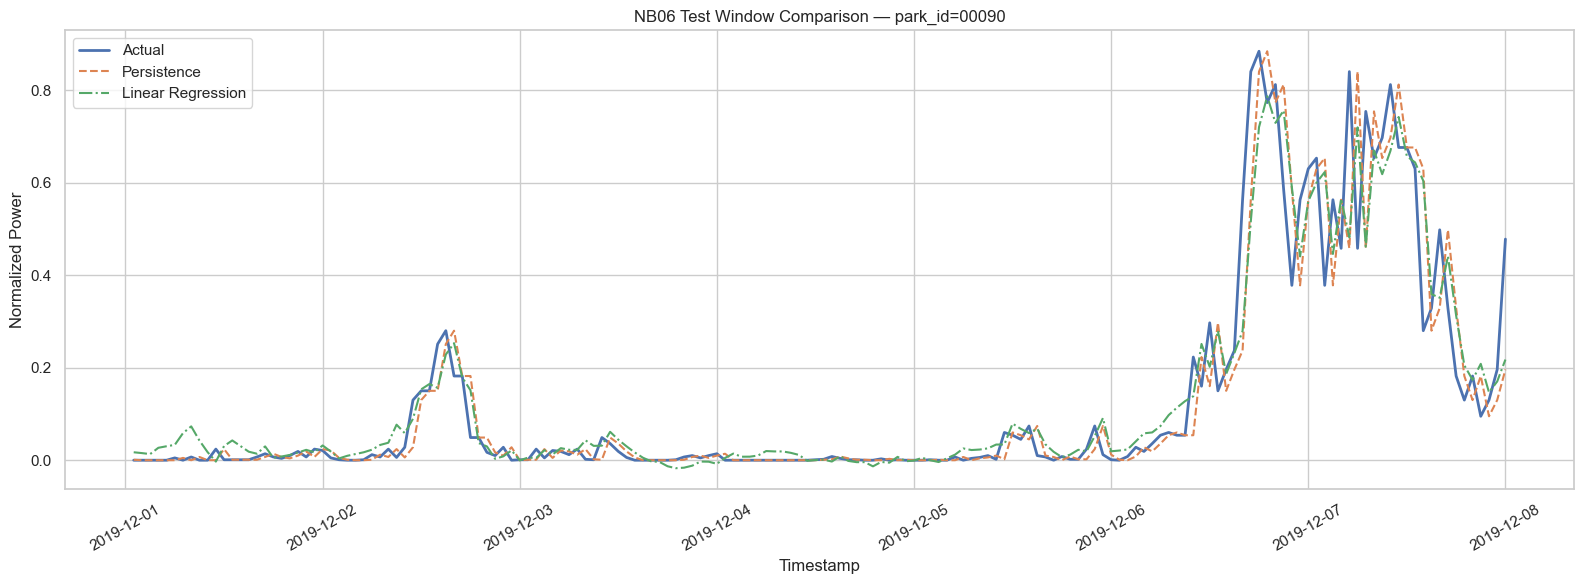

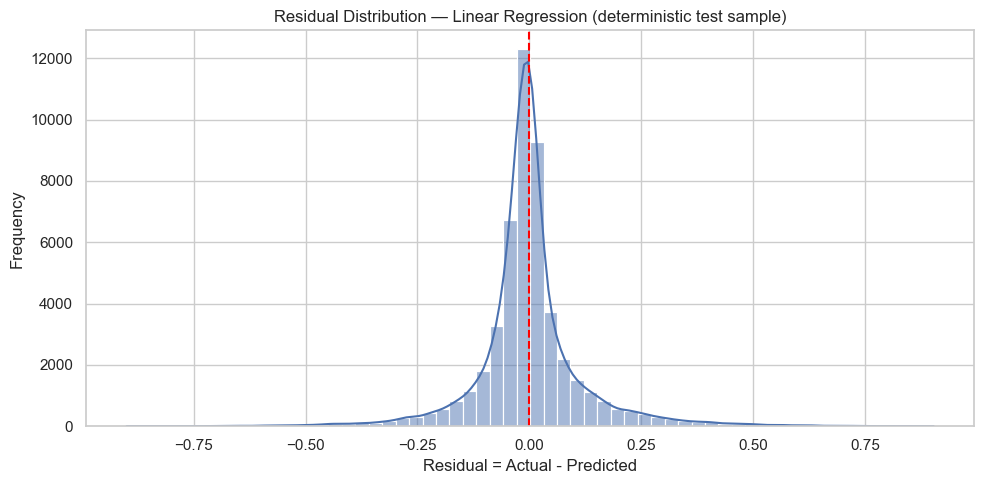

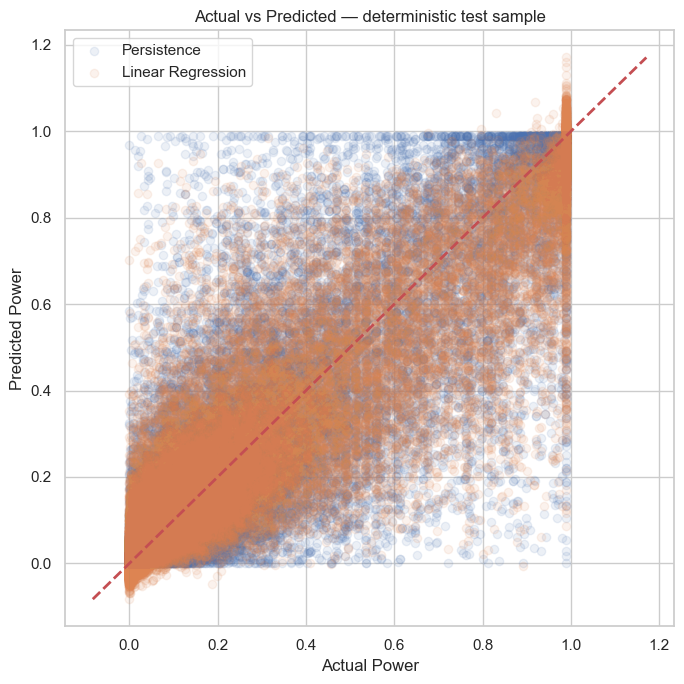

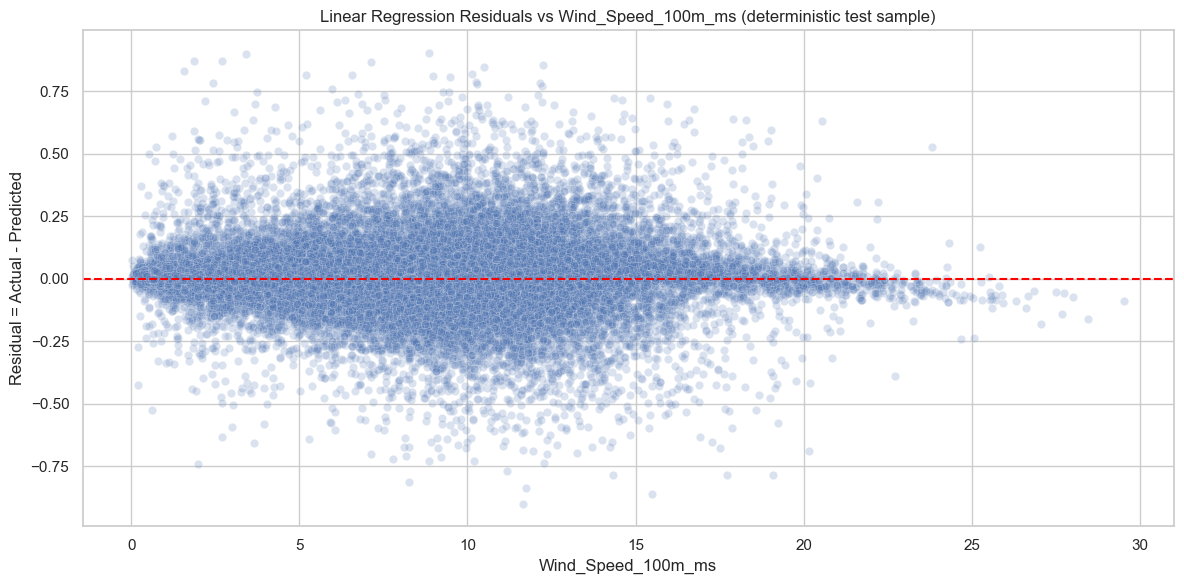

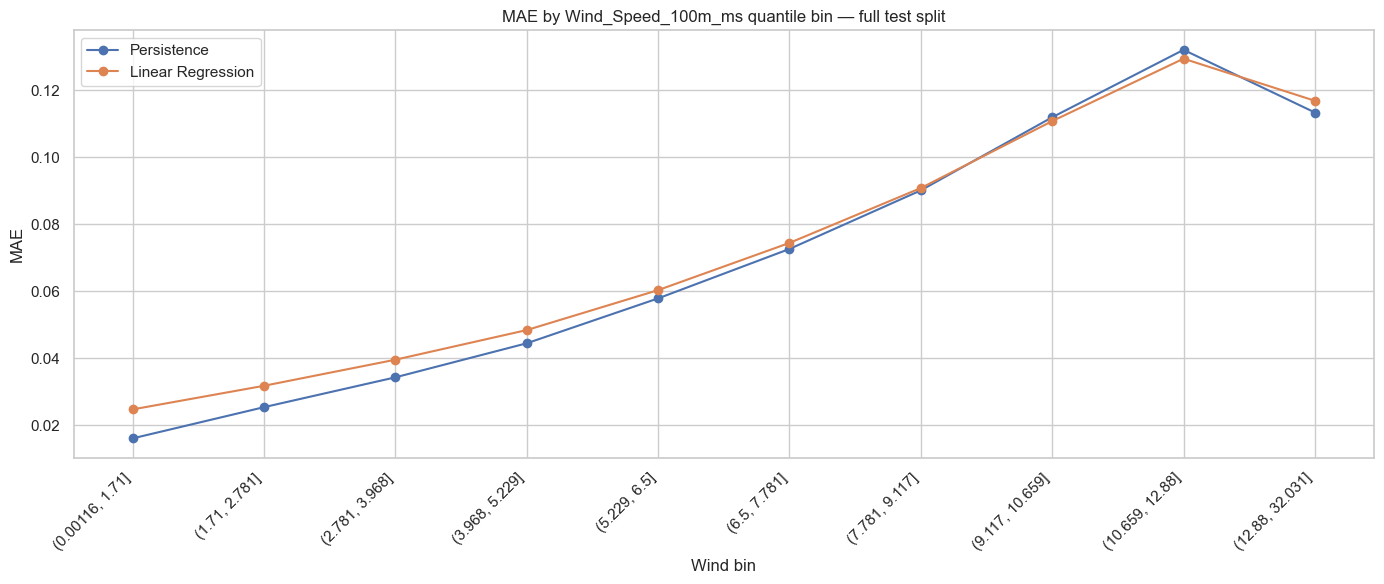

In [13]:
# ============================================================
# NB06 | Διαγνωστικά plots
# ============================================================

# ------------------------------------------------------------
# 1) Σύγκριση actual vs predicted σε deterministic time window
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(
    park_window_df[TIMESTAMP_COLUMN],
    park_window_df["y_true"],
    label="Actual",
    linewidth=2,
)
plt.plot(
    park_window_df[TIMESTAMP_COLUMN],
    park_window_df["Persistence_Pred"],
    label="Persistence",
    linestyle="--",
)
plt.plot(
    park_window_df[TIMESTAMP_COLUMN],
    park_window_df["Linear_Regression_Pred"],
    label="Linear Regression",
    linestyle="-.",
)

plt.title(f"NB06 Test Window Comparison — park_id={plot_park_id}")
plt.xlabel("Timestamp")
plt.ylabel("Normalized Power")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) Κατανομή residuals για το Linear Regression
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(
    plot_sample["Linear_Regression_Residual"],
    bins=60,
    kde=True,
)
plt.axvline(0.0, color="red", linestyle="--", linewidth=1.5)

plt.title("Residual Distribution — Linear Regression (deterministic test sample)")
plt.xlabel("Residual = Actual - Predicted")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) Actual vs Predicted scatter
# ------------------------------------------------------------
plt.figure(figsize=(7, 7))
plt.scatter(
    plot_sample["y_true"],
    plot_sample["Persistence_Pred"],
    alpha=0.10,
    label="Persistence",
)
plt.scatter(
    plot_sample["y_true"],
    plot_sample["Linear_Regression_Pred"],
    alpha=0.10,
    label="Linear Regression",
)

diag_min = min(
    plot_sample["y_true"].min(),
    plot_sample["Persistence_Pred"].min(),
    plot_sample["Linear_Regression_Pred"].min(),
)
diag_max = max(
    plot_sample["y_true"].max(),
    plot_sample["Persistence_Pred"].max(),
    plot_sample["Linear_Regression_Pred"].max(),
)

plt.plot([diag_min, diag_max], [diag_min, diag_max], "r--", linewidth=2)

plt.title("Actual vs Predicted — deterministic test sample")
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) Residuals vs wind-related feature
# ------------------------------------------------------------
if wind_col is not None:
    plt.figure(figsize=(12, 6))
    sns.scatterplot(
        data=plot_sample,
        x=wind_col,
        y="Linear_Regression_Residual",
        alpha=0.20,
    )
    plt.axhline(0.0, color="red", linestyle="--", linewidth=1.5)

    plt.title(f"Linear Regression Residuals vs {wind_col} (deterministic test sample)")
    plt.xlabel(wind_col)
    plt.ylabel("Residual = Actual - Predicted")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 5) MAE by wind bin στο full test split
    # --------------------------------------------------------
    wind_error_df = test_diag_wide[
        [wind_col, "Persistence_AbsError", "Linear_Regression_AbsError"]
    ].dropna().copy()

    wind_error_df["Wind_Bin"] = pd.qcut(
        wind_error_df[wind_col],
        q=10,
        duplicates="drop",
    )

    mae_by_bin = (
        wind_error_df
        .groupby("Wind_Bin", observed=False)[
            ["Persistence_AbsError", "Linear_Regression_AbsError"]
        ]
        .mean()
        .rename(columns={
            "Persistence_AbsError": "Persistence_MAE",
            "Linear_Regression_AbsError": "Linear_Regression_MAE",
        })
        .reset_index()
    )

    plt.figure(figsize=(14, 6))
    plt.plot(
        mae_by_bin["Wind_Bin"].astype(str),
        mae_by_bin["Persistence_MAE"],
        marker="o",
        label="Persistence",
    )
    plt.plot(
        mae_by_bin["Wind_Bin"].astype(str),
        mae_by_bin["Linear_Regression_MAE"],
        marker="o",
        label="Linear Regression",
    )

    plt.title(f"MAE by {wind_col} quantile bin — full test split")
    plt.xlabel("Wind bin")
    plt.ylabel("MAE")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Παραλείπονται τα wind-regime diagnostics γιατί δεν βρέθηκε wind-related feature.")

# Συμπέρασμα του NB06

## Τι ολοκληρώθηκε

Το `NB06` αξιολόγησε αυστηρά δύο canonical baselines:

- **Persistence**
- **Linear Regression**

χρησιμοποιώντας μόνο τα canonical split artifacts του `NB05`
και χωρίς καμία αλλαγή στο upstream feature / split contract.

---

## Τι πρέπει να ερμηνευτεί από το rerun

Η τελική σύγκριση πρέπει να βασιστεί αποκλειστικά στα **test metrics** και όχι σε γενικές διατυπώσεις.

Συγκεκριμένα, μετά το rerun πρέπει να ελεγχθεί:

- ποιο model είναι καλύτερο σε **MAE**
- ποιο model είναι καλύτερο σε **RMSE**
- ποιο model είναι καλύτερο σε **R2**
- αν υπάρχει residual structure που παραμένει μη τυχαίο
- αν τα diagnostics δικαιολογούν τη μετάβαση στο `NB07` και στο `NB08`

Σημαντικό:
το notebook **δεν** υποθέτει εκ των προτέρων ότι το `Linear Regression`
είναι καλύτερο από το `Persistence` σε όλα τα metrics.
Η ερμηνεία πρέπει να είναι αυστηρά **metric-qualified**.

---

## Canonical outputs

Το notebook εξάγει:

- `data/processed/baseline_metrics.csv`
  - μόνο με **test-set benchmark rows**
  - χωρίς validation contamination

- `data/processed/nb06_test_predictions.csv`
  - tidy row-level test predictions
  - κατάλληλο για downstream diagnostics notebooks

---

## Methodological note

Το `NB06` παραμένει αυστηρά στο forecasting scope.

Τα diagnostics εδώ είναι:

- **forecasting-oriented**
- χρήσιμα για benchmark interpretation
- χρήσιμα για downstream diagnostic slicing

αλλά **δεν** αποτελούν από μόνα τους PHM module,
fault diagnosis pipeline ή health-state inference system.